<a href="https://colab.research.google.com/github/JaimeRomeroLaguna/Sentiment-Analysis-Financial-Markets/blob/main/DictionaryStock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Necessary Libraries

In [ ]:
import pandas as pd
import pprint
import nltk
import feedparser
from langchain_community.document_loaders import NewsURLLoader
from nltk import word_tokenize
import openpyxl
from nltk.corpus import stopwords
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import requests
from langdetect import detect



In [ ]:
!pip install langchain-community
!pip install feedparser
!pip install newspaper3k
!pip install newspaper3k lxml[html_clean]
!pip install langdetect

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Compute StopWords

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Define Preprocessing function
- Tokenization
- Lowercasing
- Stop Word Removal

In [ ]:
def preprocessing(article):
    print(article)
    tokens = word_tokenize(article)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

### Dividing words into positive and negative

In [ ]:
sent_dict = pd.read_excel("Loughran-McDonald_MasterDictionary_1993-2024.xlsx")
sent_dict

,Word,Seq_num,Word Count,Word Proportion,Average Proportion,Std Dev,Doc Count,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Complexity,Syllables,Source
0,AARDVARK,1,755,2.955070e-08,1.945421e-08,4.078069e-06,140,0,0,0,0,0,0,0,0,2,12of12inf
1,AARDVARKS,2,3,1.174200e-10,8.060019e-12,8.919011e-09,1,0,0,0,0,0,0,0,0,2,12of12inf
2,ABACI,3,9,3.522600e-10,1.089343e-10,5.105359e-08,7,0,0,0,0,0,0,0,0,3,12of12inf
3,ABACK,4,29,1.135060e-09,6.197922e-10,1.539279e-07,28,0,0,0,0,0,0,0,0,2,12of12inf
4,ABACUS,5,9620,3.765268e-07,3.825261e-07,3.421836e-05,1295,0,0,0,0,0,0,0,0,3,12of12inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86548,ZYGOTE,86529,74,2.896360e-09,1.319060e-09,2.920362e-07,49,0,0,0,0,0,0,0,0,2,12of12inf
86549,ZYGOTES,86530,1,3.914000e-11,1.685075e-11,1.864660e-08,1,0,0,0,0,0,0,0,0,2,12of12inf
86550,ZYGOTIC,86531,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0,3,12of12inf
86551,ZYMURGIES,86532,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0,3,12of12inf


In [ ]:
pos_dict = sent_dict[sent_dict["Positive"] != 0]["Word"].str.lower().to_list()
neg_dict = sent_dict[sent_dict["Negative"] != 0]["Word"].str.lower().to_list()
print(pos_dict[:20])
print(neg_dict[:20])

['able', 'abundance', 'abundant', 'acclaimed', 'accomplish', 'accomplished', 'accomplishes', 'accomplishing', 'accomplishment', 'accomplishments', 'achieve', 'achieved', 'achievement', 'achievements', 'achieves', 'achieving', 'adequately', 'advancement', 'advancements', 'advances']
['abandon', 'abandoned', 'abandoning', 'abandonment', 'abandonments', 'abandons', 'abdicated', 'abdicates', 'abdicating', 'abdication', 'abdications', 'aberrant', 'aberration', 'aberrational', 'aberrations', 'abetting', 'abnormal', 'abnormalities', 'abnormality', 'abnormally']


### Sentiment Score:
Finding a way to compute negative, positive or neutral sentiment.
Definition of a function to count the words with sentiment, and a function to determine the overall sentiment of the article

In [ ]:
def countSentiment(article):
    words = article.split()
    pos_words = sum(1 for w in words if w in pos_dict)
    neg_words = sum(1 for w in words if w in neg_dict)
    return pd.Series([pos_words, neg_words])

In [ ]:
def calculateSentiment(pos_words, neg_words):
    threshold=0.3
    if pos_words + neg_words > 0 :
        sent=(pos_words-neg_words)/(pos_words+neg_words)
    else :  sent = 0
    if sent > threshold : sent = "positive"
    elif sent < -threshold : sent = "negative"
    else : sent = "neutral"
    return sent

# Test 1: Data.csv with short articles

https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis

In [ ]:
data1 = pd.read_csv("data.csv")
data1 = data1.rename(columns={"Sentence": "text", "Sentiment": "sent"})
print(data1.head())

                                                text      sent
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


In [ ]:
import nltk

# Step 1: Add your custom nltk_data path
nltk.data.path.append(r'C:\Users\Jaime Romero\nltk_data')

# Step 2: Download punkt only if not already downloaded
nltk.download('punkt', download_dir=r'C:\Users\Jaime Romero\nltk_data')

# Step 3: Now run your preprocessing that uses punkt tokenizer
data1["processed_text"] = data1["text"].apply(preprocessing)

data1[["pos_words", "neg_words"]] = data1["processed_text"].apply(countSentiment)
data1

The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .


[nltk_data] Downloading package punkt to C:\Users\Jaime
[nltk_data]     Romero\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Streaming output truncated to the last 5000 lines.
MarketsBP promotes upstream boss to deputy CEO
Britain's FTSE bounces back, Mondi and Barratt lead
Loudeye Corp. , up $ 2.56 at $ 4.33 Nokia Corp. , down 10 cents at $ 19.46 Nokia agreed to buy the digital music distributor for $ 60 million .
Ragutis , controlled by the Finnish brewery Olvi , achieved a 5.7 percent rise in beer sales to 22.6 million liters and held a 10.75 percent market share .
Finnair said that the cancellation of flights would cause daily losses of  x20ac 2.5 million US$ 3 million .
The energy sector accounted for approximately 33 % and the steel industry for about 57 % of the transportation volume .
The 5,000 megawatt wind farm being planned in Raahe would be built offshore in front of Ruukki 's Raahe Works .
The Australian company Mirabela Nickel has awarded Outokumpu Technology a contract for grinding technology for its nickel sulfide project in Bahia State , Brazil .
Standard Chartered, RBS Escape Capital Raisin

,text,sent,processed_text,pos_words,neg_words
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon 's gp...,0,0
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"$ esi lows , $ 1.50 $ 2.50 bk real possibility",0,0
2,"For the last quarter of 2010 , Componenta 's n...",positive,"last quarter 2010 , componenta 's net sales do...",0,1
3,According to the Finnish-Russian Chamber of Co...,neutral,"according finnish-russian chamber commerce , m...",0,0
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining 22.4 percen...,0,0
...,...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,rising costs forced packaging producer huhtama...,0,1
5838,Nordic Walking was first used as a summer trai...,neutral,nordic walking first used summer training meth...,0,0
5839,"According shipping company Viking Line , the E...",neutral,"according shipping company viking line , eu de...",0,0
5840,"In the building and home improvement trade , s...",neutral,"building home improvement trade , sales decrea...",1,0


In [ ]:
data1["pred_sentiment"] = data1.apply(
    lambda row: calculateSentiment(row["pos_words"], row["neg_words"]),
    axis=1
)
data1[["text","sent","pred_sentiment"]]

,text,sent,pred_sentiment
0,The GeoSolutions technology will leverage Bene...,positive,neutral
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,neutral
2,"For the last quarter of 2010 , Componenta 's n...",positive,negative
3,According to the Finnish-Russian Chamber of Co...,neutral,neutral
4,The Swedish buyout firm has sold its remaining...,neutral,neutral
...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,negative
5838,Nordic Walking was first used as a summer trai...,neutral,neutral
5839,"According shipping company Viking Line , the E...",neutral,neutral
5840,"In the building and home improvement trade , s...",neutral,positive


### Performance Metrics


Accuracy:

In [ ]:
accuracy = (data1["sent"] == data1["pred_sentiment"]).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 56.56%


Confusion Matrix:

In [ ]:


print(classification_report(data1['sent'], data1['pred_sentiment']))
cm = confusion_matrix(data1['sent'], data1['pred_sentiment'])
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

    negative       0.37      0.42      0.39       860
     neutral       0.59      0.82      0.69      3130
    positive       0.69      0.21      0.32      1852

    accuracy                           0.57      5842
   macro avg       0.55      0.48      0.47      5842
weighted avg       0.59      0.57      0.53      5842

Confusion Matrix:
 [[ 359  477   24]
 [ 428 2552  150]
 [ 172 1287  393]]


Confusion Matrix Plot:

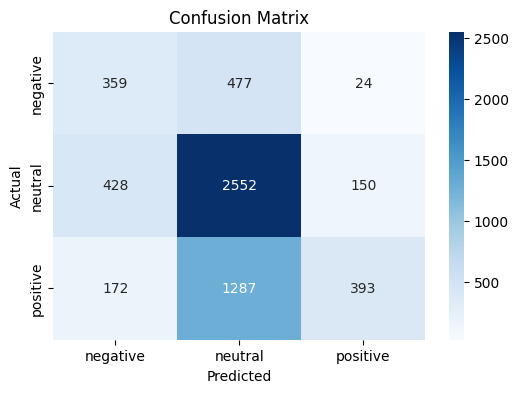

In [ ]:
labels = sorted(data1['sent'].unique())

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Test 2: Data2.csv with short articles

https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

In [ ]:
data2 = pd.read_csv("all-data.csv", header=None, encoding="latin1")
data2.columns = ["sent", "text"]
print(data2.head())

       sent                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


In [ ]:
data2["processed_text"] = data2["text"].apply(preprocessing)
data2[["pos_words", "neg_words"]] = data2["processed_text"].apply(countSentiment)
data2

According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .
The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .
With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .
According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .
FINANCING OF ASPOCOMP 'S GROWTH Aspocomp 

,sent,text,processed_text,pos_words,neg_words
0,neutral,"According to Gran , the company has no plans t...","according gran , company plans move production...",0,0
1,neutral,Technopolis plans to develop in stages an area...,technopolis plans develop stages area less 100...,0,0
2,negative,The international electronic industry company ...,international electronic industry company elco...,0,2
3,positive,With the new production plant the company woul...,new production plant company would increase ca...,2,0
4,positive,According to the company 's updated strategy f...,according company 's updated strategy years 20...,0,0
...,...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,london marketwatch -- share prices ended lower...,1,2
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,rinkuskiai 's beer sales fell 6.5 per cent 4.1...,0,0
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,operating profit fell eur 35.4 mn eur 68.8 mn ...,1,0
4844,negative,Net sales of the Paper segment decreased to EU...,net sales paper segment decreased eur 221.6 mn...,0,0


In [ ]:
data2["pred_sentiment"] = data2.apply(
    lambda row: calculateSentiment(row["pos_words"], row["neg_words"]),
    axis=1
)
data2[["text","sent","pred_sentiment"]]

,text,sent,pred_sentiment
0,"According to Gran , the company has no plans t...",neutral,neutral
1,Technopolis plans to develop in stages an area...,neutral,neutral
2,The international electronic industry company ...,negative,negative
3,With the new production plant the company woul...,positive,positive
4,According to the company 's updated strategy f...,positive,neutral
...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,negative,negative
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,neutral,neutral
4843,Operating profit fell to EUR 35.4 mn from EUR ...,negative,positive
4844,Net sales of the Paper segment decreased to EU...,negative,neutral


### Performance Metrics


Accuracy:

In [ ]:
accuracy = (data2["sent"] == data2["pred_sentiment"]).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 62.61%


Confusion Matrix:

              precision    recall  f1-score   support

    negative       0.42      0.42      0.42       604
     neutral       0.66      0.85      0.74      2879
    positive       0.61      0.25      0.35      1363

    accuracy                           0.63      4846
   macro avg       0.56      0.50      0.50      4846
weighted avg       0.62      0.63      0.59      4846

Confusion Matrix:
 [[ 253  338   13]
 [ 232 2446  201]
 [ 121  907  335]]


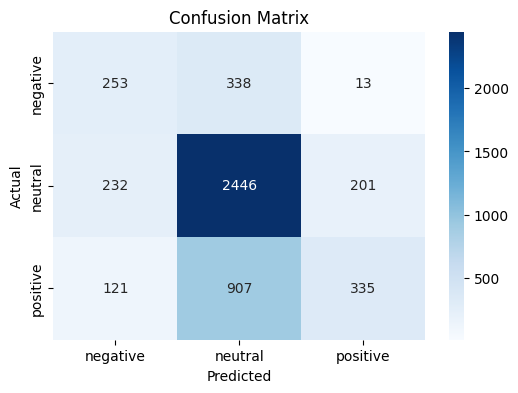

In [ ]:


print(classification_report(data2['sent'], data2['pred_sentiment']))
cm = confusion_matrix(data2['sent'], data2['pred_sentiment'])
print("Confusion Matrix:\n", cm)

labels = sorted(data2['sent'].unique())

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Test 3: Use of API for news' fetching

In [ ]:
# API setup
keyword_list = ["Boeing", "NVIDIA","Netflix"]
api_key = "3ced959e1c14479a9da362d640073231"
keyword = keyword_list[2]
from_date = "2025-20-05"
to_date = "2025-15-06"

url = (
    f"https://newsapi.org/v2/everything?"
    f"q={keyword}&from={from_date}&to={to_date}&sortBy=popularity&apiKey={api_key}"
)


response = requests.get(url)
news_data = response.json()

url_to_date = {
    article["url"]: datetime.fromisoformat(article["publishedAt"].replace("Z", "+00:00"))
    for article in news_data["articles"]
}

article_urls = [
    url for url in url_to_date.keys()
    if "consent.yahoo.com" not in url and "mensjournal.com" not in url
]



loader = NewsURLLoader(urls=article_urls)
data = loader.load()

articles = pd.DataFrame(
    [{
        "title": d.metadata["title"],
        "text": d.page_content,
        "lang": detect(d.page_content)

    } for d in data]
)

articles = articles[articles["lang"] == "en"]

articles.reset_index(drop=True, inplace=True)
articles

,title,text,lang
0,Anker Nebula X1 Home Projector Review: Gorgeou...,The world’s first home projector was the Pathé...,en
1,The US Is Building a One-Stop Shop for Buying ...,"This week, WIRED launched our Rogues issue—whi...",en
2,Netflix is removing Black Mirror: Bandersnatch,"is a news editor covering technology, gaming, ...",en
3,Netflix is bringing back Star Search as a live...,Netflix is adding an important category to its...,en
4,The oldest Fire TV devices are losing Netflix ...,is a weekend editor who covers the latest in t...,en
...,...,...,...
90,Sundar Pichai said Google thought 'intensely' ...,Sundar Pichai said he thinks about what could ...,en
91,Netflix has a new cure for decision fatigue,Netflix's new homepage will move search catego...,en
92,"Meghan Markle's career history, from acting on...",Meghan Markle was an actor before she married ...,en
93,'Big Mouth' Season 8 Voice Cast: Who Plays the...,"""Big Mouth"" season eight premieres on Friday. ...",en


In [ ]:
articles["processed_text"] = articles["text"].apply(preprocessing)

The world’s first home projector was the Pathé KOK Home Cinematograph. Launched in 1912, it used 28-millimeter film and a hand crank. Thanks to this kernel of an idea, I've just watched a film on the new Anker Nebula X1, in my garden, projected in 4K Ultra High Definition, onto a 120-inch screen, with a genuinely thrilling 4.1.2 surround-sound speaker system.

At home, I've never had the space, budget or patience to install a full-scale home cinema. But I do love the big screen, and in the pursuit of something close to a compromise I have tested dozens of superb portable projectors. As mobile technology has improved, these tiny Android-toting boxes of fun have made it possible for anyone to stream content onto a blank wall, screen, or the side of a tent. But none have come closer to looking and sounding like a proper home cinema than the Anker Nebula X1.

Photograph: Chris Haslam

Anyone familiar with Anker's range of portable projectors will recognize the X1. It looks like the big bro

In [ ]:
articles[["pos_words", "neg_words"]] = articles["processed_text"].apply(countSentiment)
articles

,title,text,lang,processed_text,pos_words,neg_words
0,Anker Nebula X1 Home Projector Review: Gorgeou...,The world’s first home projector was the Pathé...,en,world ’ first home projector pathé kok home ci...,4,2
1,The US Is Building a One-Stop Shop for Buying ...,"This week, WIRED launched our Rogues issue—whi...",en,"week , wired launched rogues issue—which inclu...",4,31
2,Netflix is removing Black Mirror: Bandersnatch,"is a news editor covering technology, gaming, ...",en,"news editor covering technology , gaming , . j...",0,2
3,Netflix is bringing back Star Search as a live...,Netflix is adding an important category to its...,en,netflix adding important category live offerin...,1,0
4,The oldest Fire TV devices are losing Netflix ...,is a weekend editor who covers the latest in t...,en,weekend editor covers latest tech entertainmen...,0,3
...,...,...,...,...,...,...
90,Sundar Pichai said Google thought 'intensely' ...,Sundar Pichai said he thinks about what could ...,en,sundar pichai said thinks could google acquire...,3,0
91,Netflix has a new cure for decision fatigue,Netflix's new homepage will move search catego...,en,netflix 's new homepage move search categories...,4,1
92,"Meghan Markle's career history, from acting on...",Meghan Markle was an actor before she married ...,en,meghan markle actor married prince harry . suz...,11,4
93,'Big Mouth' Season 8 Voice Cast: Who Plays the...,"""Big Mouth"" season eight premieres on Friday. ...",en,`` big mouth '' season eight premieres friday ...,2,0


In [ ]:
articles["sentiment"] = articles.apply(
    lambda row: calculateSentiment(row["pos_words"], row["neg_words"]),
    axis=1
)
articles[["title", "text", "sentiment"]]

,title,text,sentiment
0,Anker Nebula X1 Home Projector Review: Gorgeou...,The world’s first home projector was the Pathé...,positive
1,The US Is Building a One-Stop Shop for Buying ...,"This week, WIRED launched our Rogues issue—whi...",negative
2,Netflix is removing Black Mirror: Bandersnatch,"is a news editor covering technology, gaming, ...",negative
3,Netflix is bringing back Star Search as a live...,Netflix is adding an important category to its...,positive
4,The oldest Fire TV devices are losing Netflix ...,is a weekend editor who covers the latest in t...,negative
...,...,...,...
90,Sundar Pichai said Google thought 'intensely' ...,Sundar Pichai said he thinks about what could ...,positive
91,Netflix has a new cure for decision fatigue,Netflix's new homepage will move search catego...,positive
92,"Meghan Markle's career history, from acting on...",Meghan Markle was an actor before she married ...,positive
93,'Big Mouth' Season 8 Voice Cast: Who Plays the...,"""Big Mouth"" season eight premieres on Friday. ...",positive


In [ ]:
sentiment_counts = articles["sentiment"].value_counts()
print(sentiment_counts)
majority_sentiment = sentiment_counts.idxmax()
print(f"The majority of the articles are: {majority_sentiment}")

sentiment
positive    40
negative    30
neutral     25
Name: count, dtype: int64
The majority of the articles are: positive


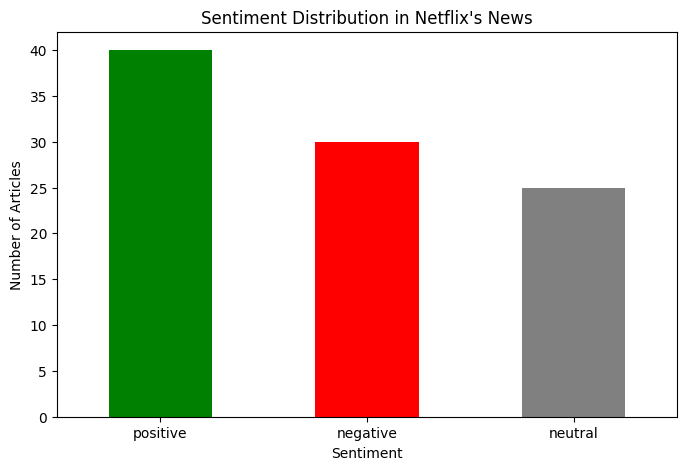

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = articles["sentiment"].value_counts()

color_map = {
    "positive": "green",
    "negative": "red",
    "neutral": "gray"
}
colors = [color_map[sentiment] for sentiment in sentiment_counts.index]

# Plot
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar", color=colors)
plt.title(f"Sentiment Distribution in {keyword}'s News")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.show()


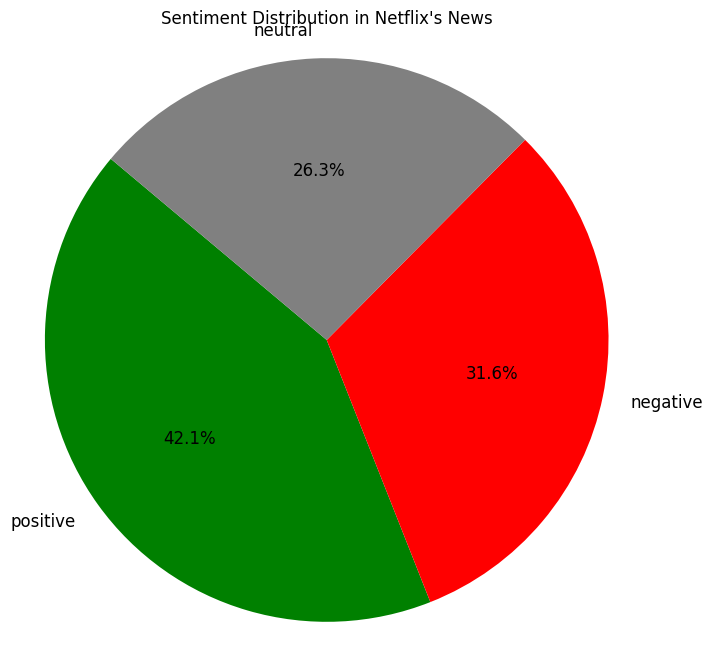

In [ ]:
plt.figure(figsize=(8, 8))  # Pie charts look better with a square figure

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',  # Show percentages
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title(f"Sentiment Distribution in {keyword}'s News")
plt.axis('equal')  # Equal aspect ratio to make the pie circular
plt.show()
